# Análisis Exploratorio de Datos: vgchartz.csv

**Autor:** Miguel Angel Condori
**Fecha:** Junio 2026
**Dataset:** "https://www.kaggle.com/datasets/gsimonx37/vgchartz"

## Introducción
Este analisis explora el dataset vgchartz.csv relacionado con videojuego y ventas.
El mismo esta compuesto por 11 columnas/variables y 16324 filas/registros.
Los objetivos son:
1. Hallar el genero que mas vendio globalmente los ultimos diez años.
2. Hallar la plataforma con mas titulos exitosos.
3. Analizar la evolucion de ventas por region a lo largo del tiempo.
4. Analizar que publisher vende mejor en Norteamerica vs Japon.
5. Analizar como influye en las ventas globales las ventas en NA.


Importamos las librerias de python a utilizar y el dataset.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df = pd.read_csv(r"../data/vgsales.csv")
df.shape

(16324, 11)

# Analisis del dataset

In [45]:
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16324 entries, 0 to 16323
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16324 non-null  int64  
 1   Name          16324 non-null  object 
 2   Platform      16324 non-null  object 
 3   Year          16324 non-null  int64  
 4   Genre         16324 non-null  object 
 5   Publisher     16288 non-null  object 
 6   NA_Sales      16324 non-null  float64
 7   EU_Sales      16324 non-null  float64
 8   JP_Sales      16324 non-null  float64
 9   Other_Sales   16324 non-null  float64
 10  Global_Sales  16324 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.4+ MB


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,259,Asteroids,2600,1980,Shooter,Atari,4.00,0.26,0.0,0.05,4.31
1,545,Missile Command,2600,1980,Shooter,Atari,2.56,0.17,0.0,0.03,2.76
2,1768,Kaboom!,2600,1980,Misc,Activision,1.07,0.07,0.0,0.01,1.15
3,1971,Defender,2600,1980,Misc,Atari,0.99,0.05,0.0,0.01,1.05
4,2671,Boxing,2600,1980,Fighting,Activision,0.72,0.04,0.0,0.01,0.77
5,4027,Ice Hockey,2600,1980,Sports,Activision,0.46,0.03,0.0,0.01,0.49
6,5368,Freeway,2600,1980,Action,Activision,0.32,0.02,0.0,0.00,0.34
7,6319,Bridge,2600,1980,Misc,Activision,0.25,0.02,0.0,0.00,0.27
8,6898,Checkers,2600,1980,Misc,Atari,0.22,0.01,0.0,0.00,0.24
9,240,Pitfall!,2600,1981,Platform,Activision,4.21,0.24,0.0,0.05,4.50


Podemos ver que el dataset incluye columnas Name y Rank, las cuales no nos sirver para el objetivo que queremos.
Por ello mismo las eliminaremos.
Y no contiene datos nulos/vacios (NaN).
- Sin nulos
- Eliminamos la columna Name, y la columna Rank.


In [46]:
df.drop(["Name", "Rank"], axis=1, inplace=True)

## Cuales fueron los videojugos mas vendidos en los ultimos 10 años?
Ahora queremos ver cuales son los juegos mas vendidos en los ultimos 10 años. Podemos ver que el dataset recopila datos de 1980 a 2016.
Por lo cual usaremos los años de 2006-2016.
Igual, solo ocupamos utiliza la columnas de genero, año y ventas globales.

In [47]:
df.Year.value_counts()
df["Year"].unique()

array([1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990,
       1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001,
       2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016])

In [48]:
Ultimos10Anios = df[df["Year"] >= 2006][["Year","Genre", "Global_Sales"]]
Ultimos10Anios.head(10)
Ultimos10Anios["Year"].unique()
Ultimos10Anios["Genre"].unique()

array(['Sports', 'Platform', 'Misc', 'Role-Playing', 'Action', 'Shooter',
       'Simulation', 'Racing', 'Puzzle', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [49]:
Ultimos10Anios.groupby("Genre")["Global_Sales"].sum()

Genre
Action          1122.32
Adventure        142.69
Fighting         189.77
Misc             561.64
Platform         282.87
Puzzle            92.04
Racing           301.80
Role-Playing     515.32
Shooter          701.61
Simulation       222.54
Sports           793.02
Strategy          73.84
Name: Global_Sales, dtype: float64

Podemos ver que de todos los generos el mas vendido fue el genero de Accion.
Lo dejaremos mejor ilustrado con el siguiente grafico.

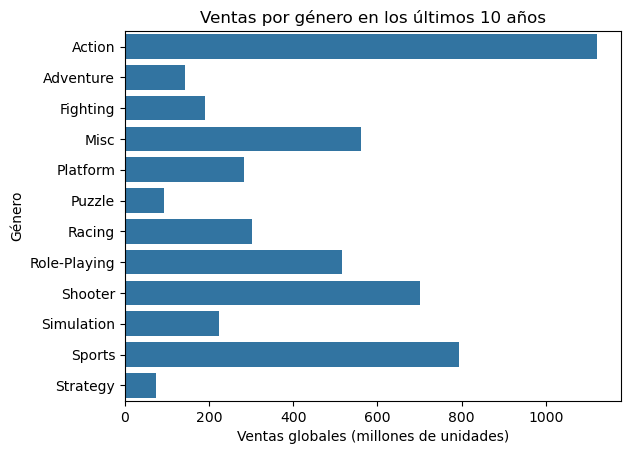

In [50]:
ventas = Ultimos10Anios.groupby("Genre")["Global_Sales"].sum()
sns.barplot(x=ventas.values, y=ventas.index)
plt.title("Ventas por género en los últimos 10 años")
plt.xlabel("Ventas globales (millones de unidades)")
plt.ylabel("Género")
plt.savefig(
    "../images/ventas_por_genero_ultimos_10_anios.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

En conclusion el genero mas taquillero es el de Accion.

## Cuales son las plataformas con mas titulos exitosos?
Ahora tenemos que analizar las plataformas con mas titulos exitosos, por "titulos exitosos" nos referimos a titulos con mas de 1 millon de ventas.
Comenzaremos creando un dataset con un requerimiento.
Y solo ocuparemos las columnas de Global Sales y Platform

In [51]:
titulosExitosos = df[df["Global_Sales"] >= 1][["Platform", "Global_Sales"]]
plataformasExitosas = titulosExitosos.groupby("Platform").count()
plataformasExitosas.head(31)

,Global_Sales
Platform,
2600,23
3DS,47
DC,6
DS,144
GB,54
GBA,69
GC,46
GEN,11
N64,51


Ya tenemos la nocion del aproximado, ahora los mostramos en un grafico para que sea mas ilustrativo.

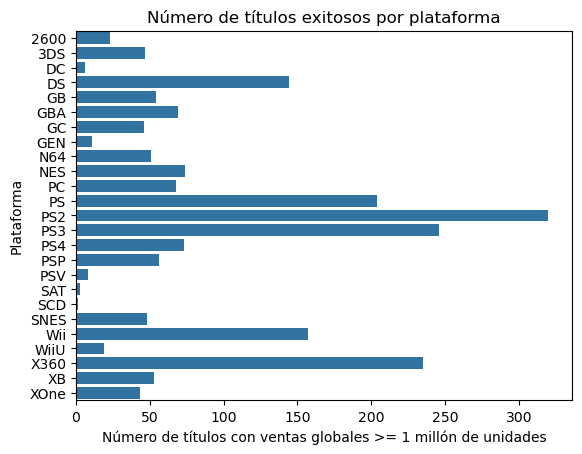

In [52]:
sns.barplot(x=plataformasExitosas["Global_Sales"], y=plataformasExitosas.index)
plt.title("Número de títulos exitosos por plataforma")
plt.xlabel("Número de títulos con ventas globales >= 1 millón de unidades")
plt.ylabel("Plataforma")
plt.savefig(
    "../images/exitos_por_plataforma.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

La Plataforma que mas titulos exitosos tuvo es la PS2 cono 320 juegos exitosos.

## Como evolucionarion las ventas en cada region a traves de los años?
Ahora analizaremos las ventas de videojuegos por regiones a traves del tiempo, para esto crearemos un dataset.
Este dataset solo ocupa las columnas que representas las ventas por region y la colmna "Year".

In [53]:
regiones = df[["EU_Sales", "NA_Sales", "JP_Sales", "Other_Sales", "Year"]]
regiones.head(10)
ventas_anuales = regiones.groupby("Year").sum()
print(ventas_anuales)

      EU_Sales  NA_Sales  JP_Sales  Other_Sales
Year                                           
1980      0.67     10.59      0.00         0.12
1981      1.96     33.40      0.00         0.32
1982      1.65     26.92      0.00         0.31
1983      0.80      7.76      8.10         0.14
1984      2.10     33.28     14.27         0.70
1985      4.74     33.73     14.56         0.92
1986      2.84     12.50     19.81         1.93
1987      1.41      8.46     11.63         0.20
1988      6.59     23.87     15.76         0.99
1989      8.44     45.15     18.36         1.50
1990      7.63     25.46     14.88         1.40
1991      3.95     12.76     14.78         0.74
1992     11.71     33.87     28.91         1.65
1993      4.65     15.12     25.33         0.89
1994     14.88     28.15     33.99         2.20
1995     14.90     24.82     45.75         2.64
1996     47.26     86.76     57.44         7.69
1997     48.32     94.75     48.87         9.13
1998     66.90    128.36     50.04      

Observamos que se alcanzan picos entre 2005 y 2010, y la ventas se van reduciendo a partir de ese punto, para dejarlo mejor ilustrado tenemos el siguiente grafico:

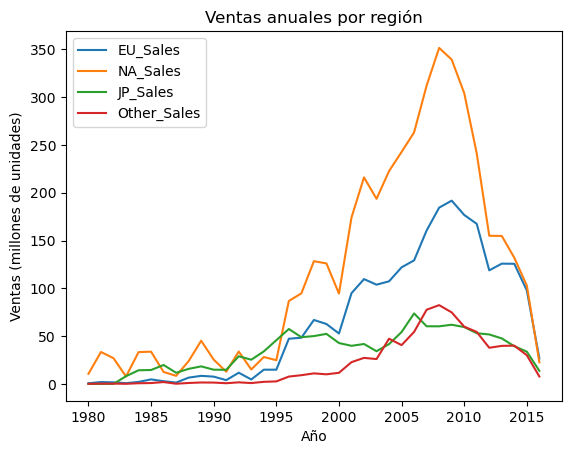

In [54]:
plt.title("Ventas anuales por región")
plt.xlabel("Año")
plt.ylabel("Ventas (millones de unidades)")
for region in ["EU_Sales", "NA_Sales", "JP_Sales", "Other_Sales"]:
    sns.lineplot(
        x=ventas_anuales.index,
        y=ventas_anuales[region],
        label=region
    )
plt.savefig(
    "../images/ventas_anuales_por_region.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

En conclusion se aprecia un pico entre 2005 y 2010. Y de ahi una baja, y una gran baja especialemnte en mercado norte americano.

## Publishers mas taquilleros, comparacion Japon - Norte America
Ahora queremos analizar que publisher venden mejor en el mercado japones vs el mercado norteamericano, para esto usamos un dataset el cual solo ocupara las columnas de ventas en las regiones de japon y norteamerica, y los publisher.

In [55]:
publisher = df[["Publisher", "NA_Sales", "JP_Sales"]]
publisher.groupby("Publisher").sum().sort_values(by="NA_Sales", ascending=False).head(10)

,NA_Sales,JP_Sales
Publisher,,
Nintendo,815.75,454.99
Electronic Arts,584.22,13.98
Activision,426.01,6.54
Sony Computer Entertainment,265.22,74.10
Ubisoft,252.81,7.33
Take-Two Interactive,220.47,5.83
THQ,208.60,5.01
Microsoft Game Studios,155.35,3.26
Sega,108.78,56.15


Podemos ver los publisher, en el caso de norte america, como estos varian respecto a su posicion el mercado japones, donde el que mejor se mantiene es Nintendo.

In [56]:
publisher.groupby("Publisher").sum().sort_values(by="JP_Sales", ascending=False).head(10)

,NA_Sales,JP_Sales
Publisher,,
Nintendo,815.75,454.99
Namco Bandai Games,69.38,126.84
Konami Digital Entertainment,88.91,90.93
Sony Computer Entertainment,265.22,74.10
Capcom,78.45,67.38
Sega,108.78,56.15
Square Enix,48.59,49.79
SquareSoft,11.06,40.13
Enix Corporation,0.76,32.40


Aqui vemos el contrario, y confirmamos que el mas vendido en ambas regiones es Nintendo.
Dejaremos ver estas dos comparaciones en la siguiente tabla.

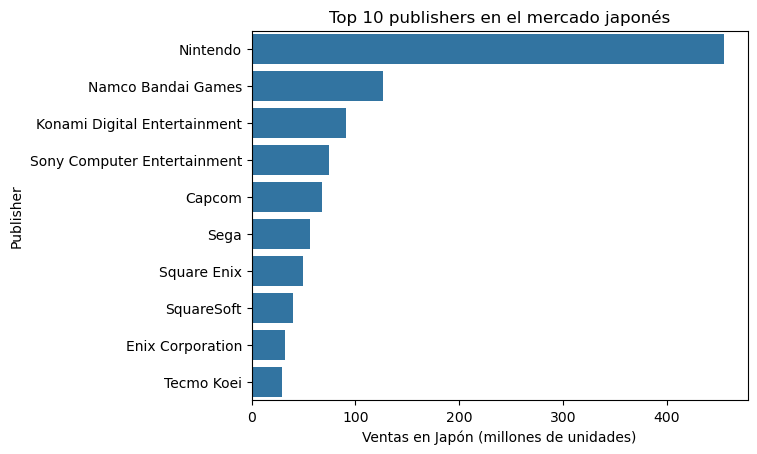

In [57]:
topMercadoJapones = publisher.groupby("Publisher").sum().sort_values(by="JP_Sales", ascending=False).head(10)
sns.barplot(x=topMercadoJapones["JP_Sales"].values, y=topMercadoJapones.index)
plt.title("Top 10 publishers en el mercado japonés")
plt.xlabel("Ventas en Japón (millones de unidades)")
plt.ylabel("Publisher")
plt.savefig(
    "../images/top_publishers_japones.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

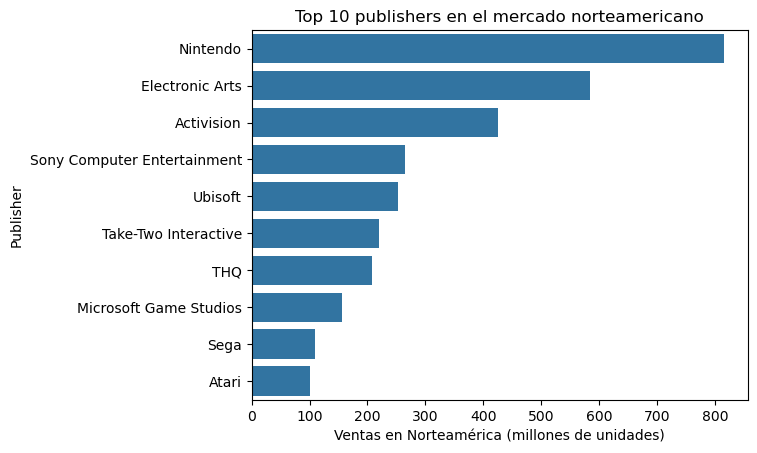

In [58]:
topMercadoNorteAmericano = publisher.groupby("Publisher").sum().sort_values(by="NA_Sales", ascending=False).head(10)
sns.barplot(x=topMercadoNorteAmericano["NA_Sales"].values, y=topMercadoNorteAmericano.index)
plt.title("Top 10 publishers en el mercado norteamericano")
plt.xlabel("Ventas en Norteamérica (millones de unidades)")
plt.ylabel("Publisher")
plt.savefig(
    "../images/top_publishers_norteamericano.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

En conclusion, el que mejor vende en ambos mercados en Nintendo.

## Influencia del mercado Norte Americano en el mercado global
Ahora veremos la correlacion entre el mercado norte americano y el mercado global.

In [59]:
correlacion = df["NA_Sales"].corr(df["Global_Sales"])
print(f"Correlación entre NA_Sales y Global_Sales: {correlacion:.3f}")

Correlación entre NA_Sales y Global_Sales: 0.941


El mercado norte americano tiene una correlacion muy fuerte con el mercado global 

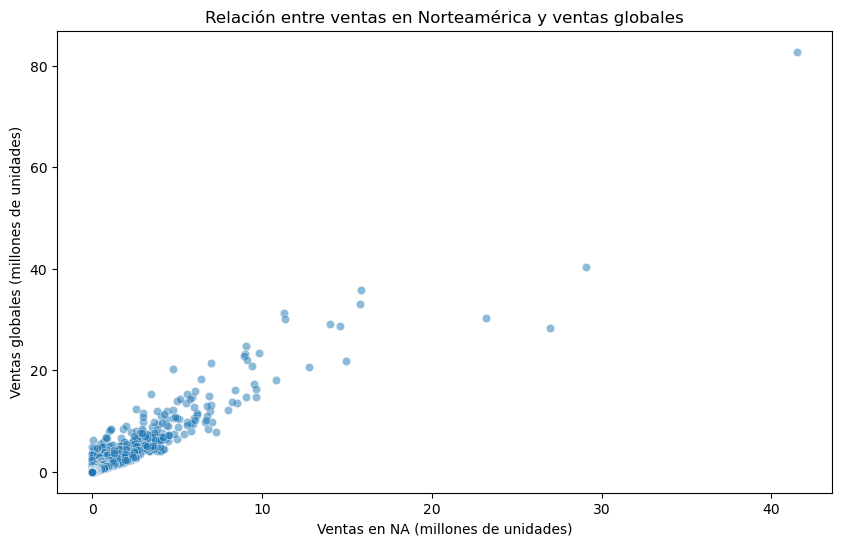

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x="NA_Sales", y="Global_Sales", data=df, alpha=0.5)
plt.title("Relación entre ventas en Norteamérica y ventas globales")
plt.xlabel("Ventas en NA (millones de unidades)")
plt.ylabel("Ventas globales (millones de unidades)")
plt.show()

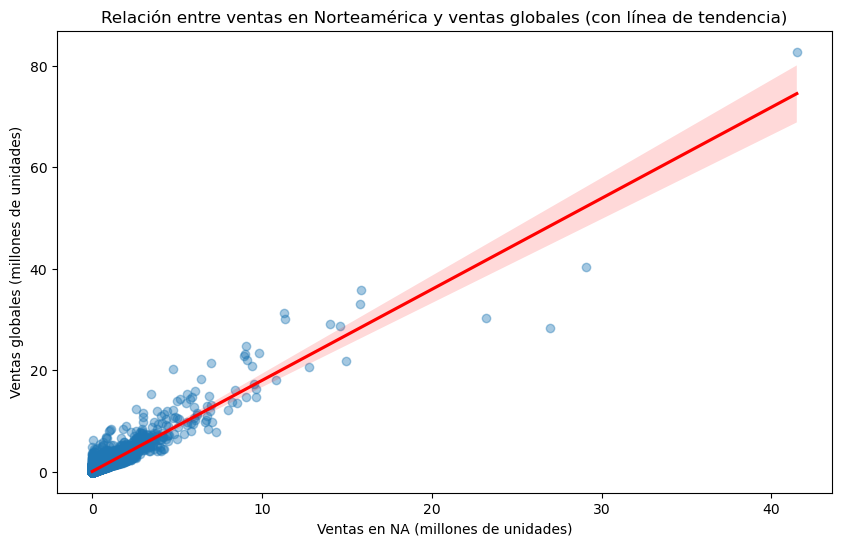

In [61]:
plt.figure(figsize=(10,6))
sns.regplot(x="NA_Sales", y="Global_Sales", data=df, scatter_kws={"alpha":0.4}, line_kws={"color":"red"})
plt.title("Relación entre ventas en Norteamérica y ventas globales (con línea de tendencia)")
plt.xlabel("Ventas en NA (millones de unidades)")
plt.ylabel("Ventas globales (millones de unidades)")
plt.savefig(
    "../images/relacion_ventas_na_globales_regplot.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

Conclusion: El mercado norte americano representa una gran parte del mercado mundial, por lo cual su correlacion es fuerte.

## Conclusiones: 

    Acción fue el género más vendido.
    PS2 tuvo la mayor cantidad de títulos exitosos.
    Norteamérica domina las ventas globales.
    Existio una caida fuerte entre 2010 y 2016
    Nintendo lidera tanto Japón como Norteamérica.
    Existe una fuerte correlación entre ventas en Norteamérica y ventas globales.